In [1]:
!pip install -q "transformers>=4.40.0" datasets peft accelerate bitsandbytes tqdm



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 13.2 MB/s eta 0:00:00


In [2]:
!pip install evaluate bert-score sentence-transformers


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.5 MB/s eta 0:00:00


In [3]:
import os
if "COLAB_GPU" in os.environ:
  from google.colab import output
  output.enable_custom_widget_manager()

In [ ]:
import os
from huggingface_hub import notebook_login

# If running in Google Colab
if "COLAB_GPU" in os.environ:
    !huggingface-cli login
# If running locally (Jupyter, VS Code, etc.)
else:
    notebook_login() 


⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.

    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To log in, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) Y
Token is valid (permission: read).
The token `lk` has been saved to /root/.cache/huggingface/stored_tokens
Cannot authenticate through git-credential as no 

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
import torch

model_name = "Qwen/Qwen2-0.5B-Instruct"
adapter_name = "ZunairAhmad/qwen2-mental-health"

device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

model = PeftModel.from_pretrained(base, adapter_name)
model.eval()


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

adapter_config.json: 0.00B [00:00, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/8.68M [00:00<?, ?B/s]

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 896)
        (layers): ModuleList(
          (0-23): 24 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=896, out_features=896, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=896, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=896, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
     

In [6]:
from datasets import load_dataset

ds = load_dataset("Amod/mental_health_counseling_conversations")
split = ds["train"].train_test_split(test_size=0.30, seed=42)
test_ds = split["test"]

print(len(test_ds), "evaluation samples loaded")


README.md: 0.00B [00:00, ?B/s]

combined_dataset.json: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/3512 [00:00<?, ? examples/s]

1054 evaluation samples loaded


**Generation function**

In [ ]:
def generate_response(context, max_new_tokens=128):
    
    prompt = (
        "<|im_start|>user\n"
        f"{context}\n"
        "<|im_end|>\n"
        "<|im_start|>assistant\n"
    )

    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=False)

  
    if "<|im_start|>assistant" in decoded:
        answer = decoded.split("<|im_start|>assistant")[-1]
        if "<|im_end|>" in answer:
            answer = answer.split("<|im_end|>")[0]
        return answer.strip()

    return decoded.strip()


**Generate predictions for evaluation**

In [8]:
from tqdm.auto import tqdm

preds = []
refs = []

for sample in tqdm(test_ds, desc="Generating model responses", colour="green"):
    context = sample["Context"]
    reference = sample["Response"]

    prediction = generate_response(context)

    preds.append(prediction)
    refs.append(reference)


Generating model responses:   0%|          | 0/1054 [00:00<?, ?it/s]

**ROUGE Score**

In [10]:
!pip install rouge_score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=ac1ff0a7486bcf74b6a67456be8f3361594558debb207b33cb76552765534286
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge_score


In [11]:
import evaluate

rouge = evaluate.load("rouge")
rouge_scores = rouge.compute(predictions=preds, references=refs)

print("ROUGE Scores:")
print(rouge_scores)


ROUGE Scores:
{'rouge1': np.float64(0.27503151844933693), 'rouge2': np.float64(0.03752474100482501), 'rougeL': np.float64(0.13496287552261174), 'rougeLsum': np.float64(0.13714025991418352)}


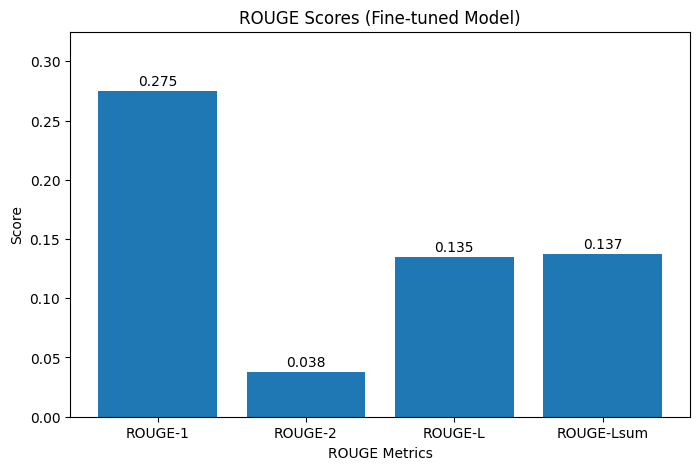

In [12]:
import matplotlib.pyplot as plt

# Use ROUGE results from your code
scores = {
    "ROUGE-1": rouge_scores["rouge1"],
    "ROUGE-2": rouge_scores["rouge2"],
    "ROUGE-L": rouge_scores["rougeL"],
    "ROUGE-Lsum": rouge_scores["rougeLsum"]
}

metrics = list(scores.keys())
values = list(scores.values())

plt.figure(figsize=(8, 5))
plt.bar(metrics, values)

plt.xlabel("ROUGE Metrics")
plt.ylabel("Score")
plt.title("ROUGE Scores (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()


**BERTScore**

In [13]:
bertscore = evaluate.load("bertscore")
bert_scores = bertscore.compute(
    predictions=preds,
    references=refs,
    lang="en"
)

print("BERTScore F1:", sum(bert_scores["f1"])/len(bert_scores["f1"]))


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore F1: 0.8404730578753709


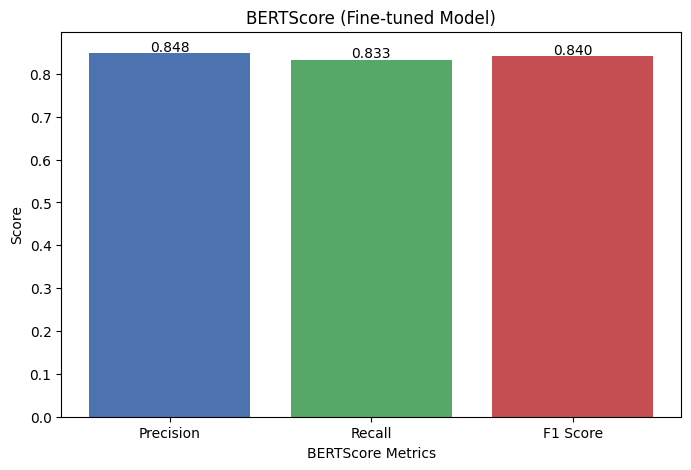

In [14]:
import matplotlib.pyplot as plt

# Extract average precision, recall, F1 from bert_scores
bert_p = sum(bert_scores["precision"]) / len(bert_scores["precision"])
bert_r = sum(bert_scores["recall"]) / len(bert_scores["recall"])
bert_f1 = sum(bert_scores["f1"]) / len(bert_scores["f1"])

metrics = ["Precision", "Recall", "F1 Score"]
values = [bert_p, bert_r, bert_f1]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=["#4C72B0", "#55A868", "#C44E52"])

plt.xlabel("BERTScore Metrics")
plt.ylabel("Score")
plt.title("BERTScore (Fine-tuned Model)")
plt.ylim(0, max(values) + 0.05)

# Add text labels on top of bars
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center')

plt.show()
